In [1]:
import os
import pandas as pd
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Thiết lập đường dẫn tới thư mục artifacts (nơi chứa file pkl và csv)
# Nếu file .ipynb nằm cùng thư mục với file script cũ, BASE_DIR sẽ là thư mục cha.
# Bạn có thể điều chỉnh lại đường dẫn cho đúng với cấu trúc thư mục của mình.
BASE_DIR = os.path.dirname(os.getcwd()) # Lấy thư mục cha của thư mục hiện tại
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'artifacts')

print(f"📂 Thư mục chứa artifacts: {ARTIFACTS_DIR}")

📂 Thư mục chứa artifacts: d:\Duy\ADY\Project_ADY201m_GR01_AI2009_H1\artifacts


In [2]:
# 1. Load các tập dữ liệu Train/Test đã chia sẵn
X_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_train.csv'))
X_test = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_test.csv'))
y_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_train.csv'))
y_test = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_test.csv'))

# 2. Load Pipeline tiền xử lý (chỉ chứa bước One-Hot Encoder)
preprocessing_pipeline = joblib.load(os.path.join(ARTIFACTS_DIR, 'preprocessing_pipeline.pkl'))

print("✅ Đã load thành công dữ liệu và pipeline vào Notebook!")
print(f"Kích thước tập X_train gốc: {X_train.shape}")

✅ Đã load thành công dữ liệu và pipeline vào Notebook!
Kích thước tập X_train gốc: (5634, 25)


c:\Users\Muich\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


         MODEL PERFORMANCE METRICS SUMMARY REPORT
   Metric Train Set Test Set
 Accuracy    0.8133   0.7949
Precision    0.6751   0.6300
   Recall    0.5712   0.5508
 F1-score    0.6188   0.5877
  ROC-AUC    0.8606   0.8519


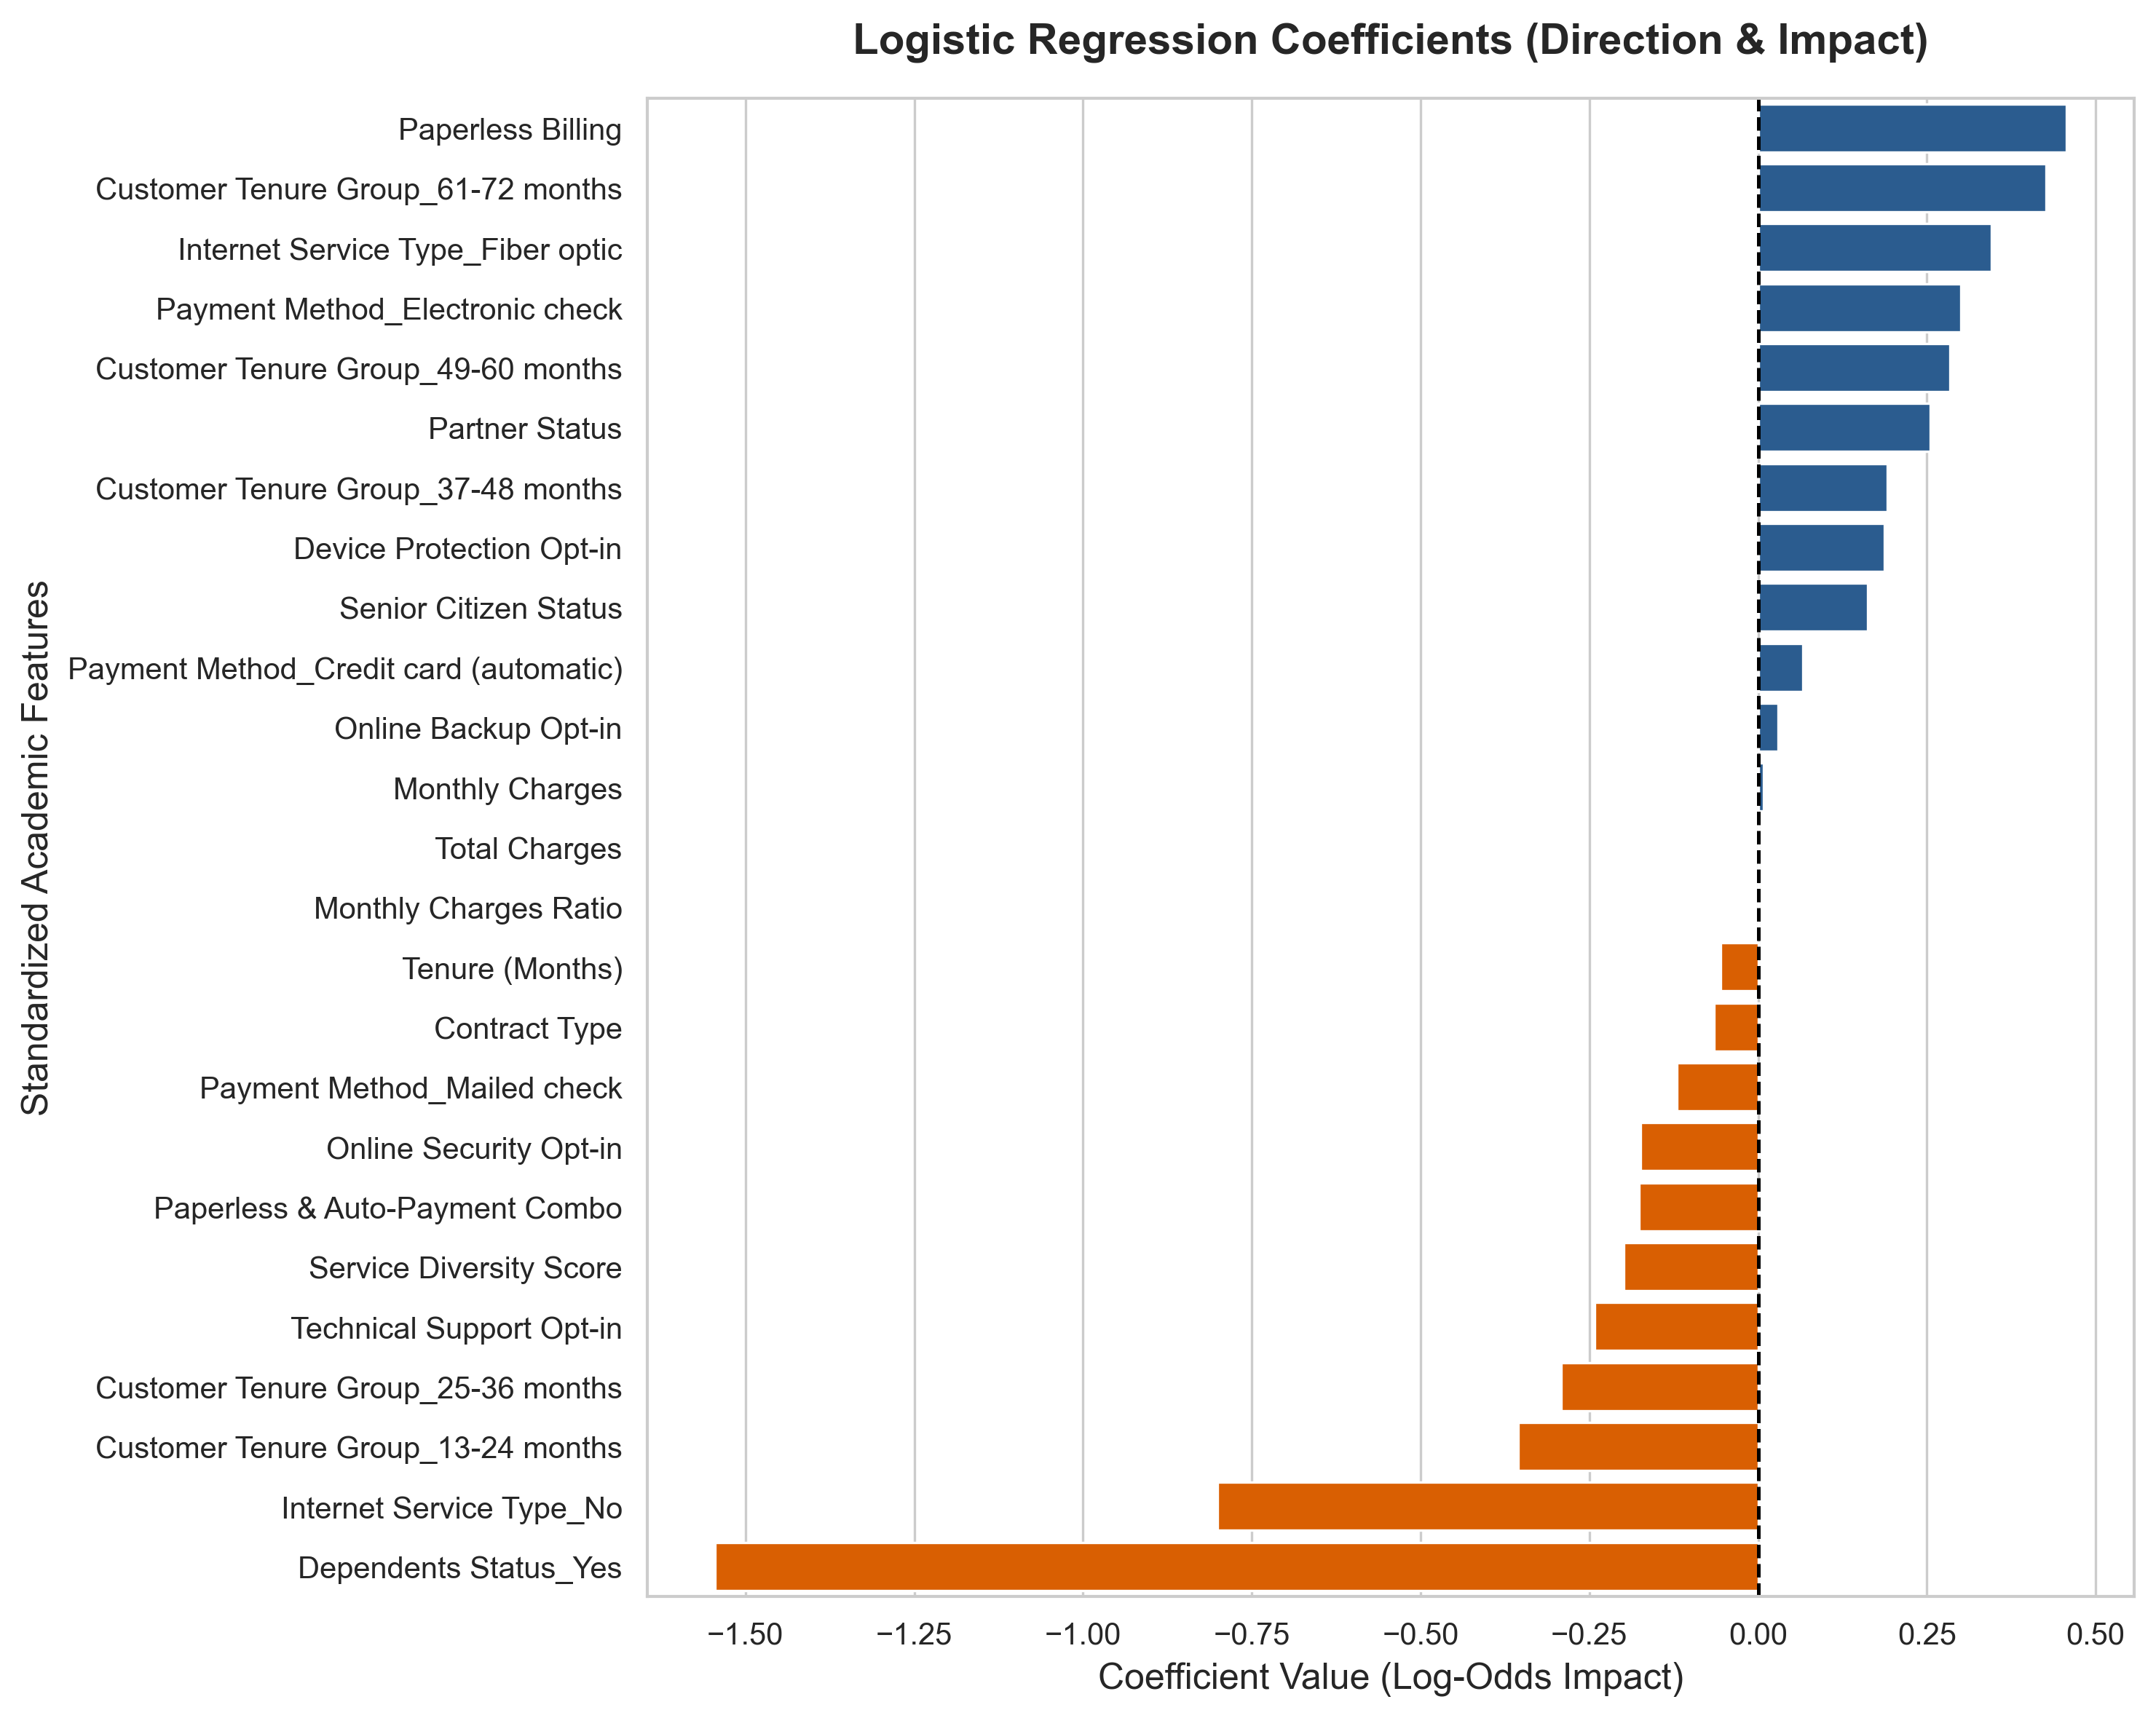

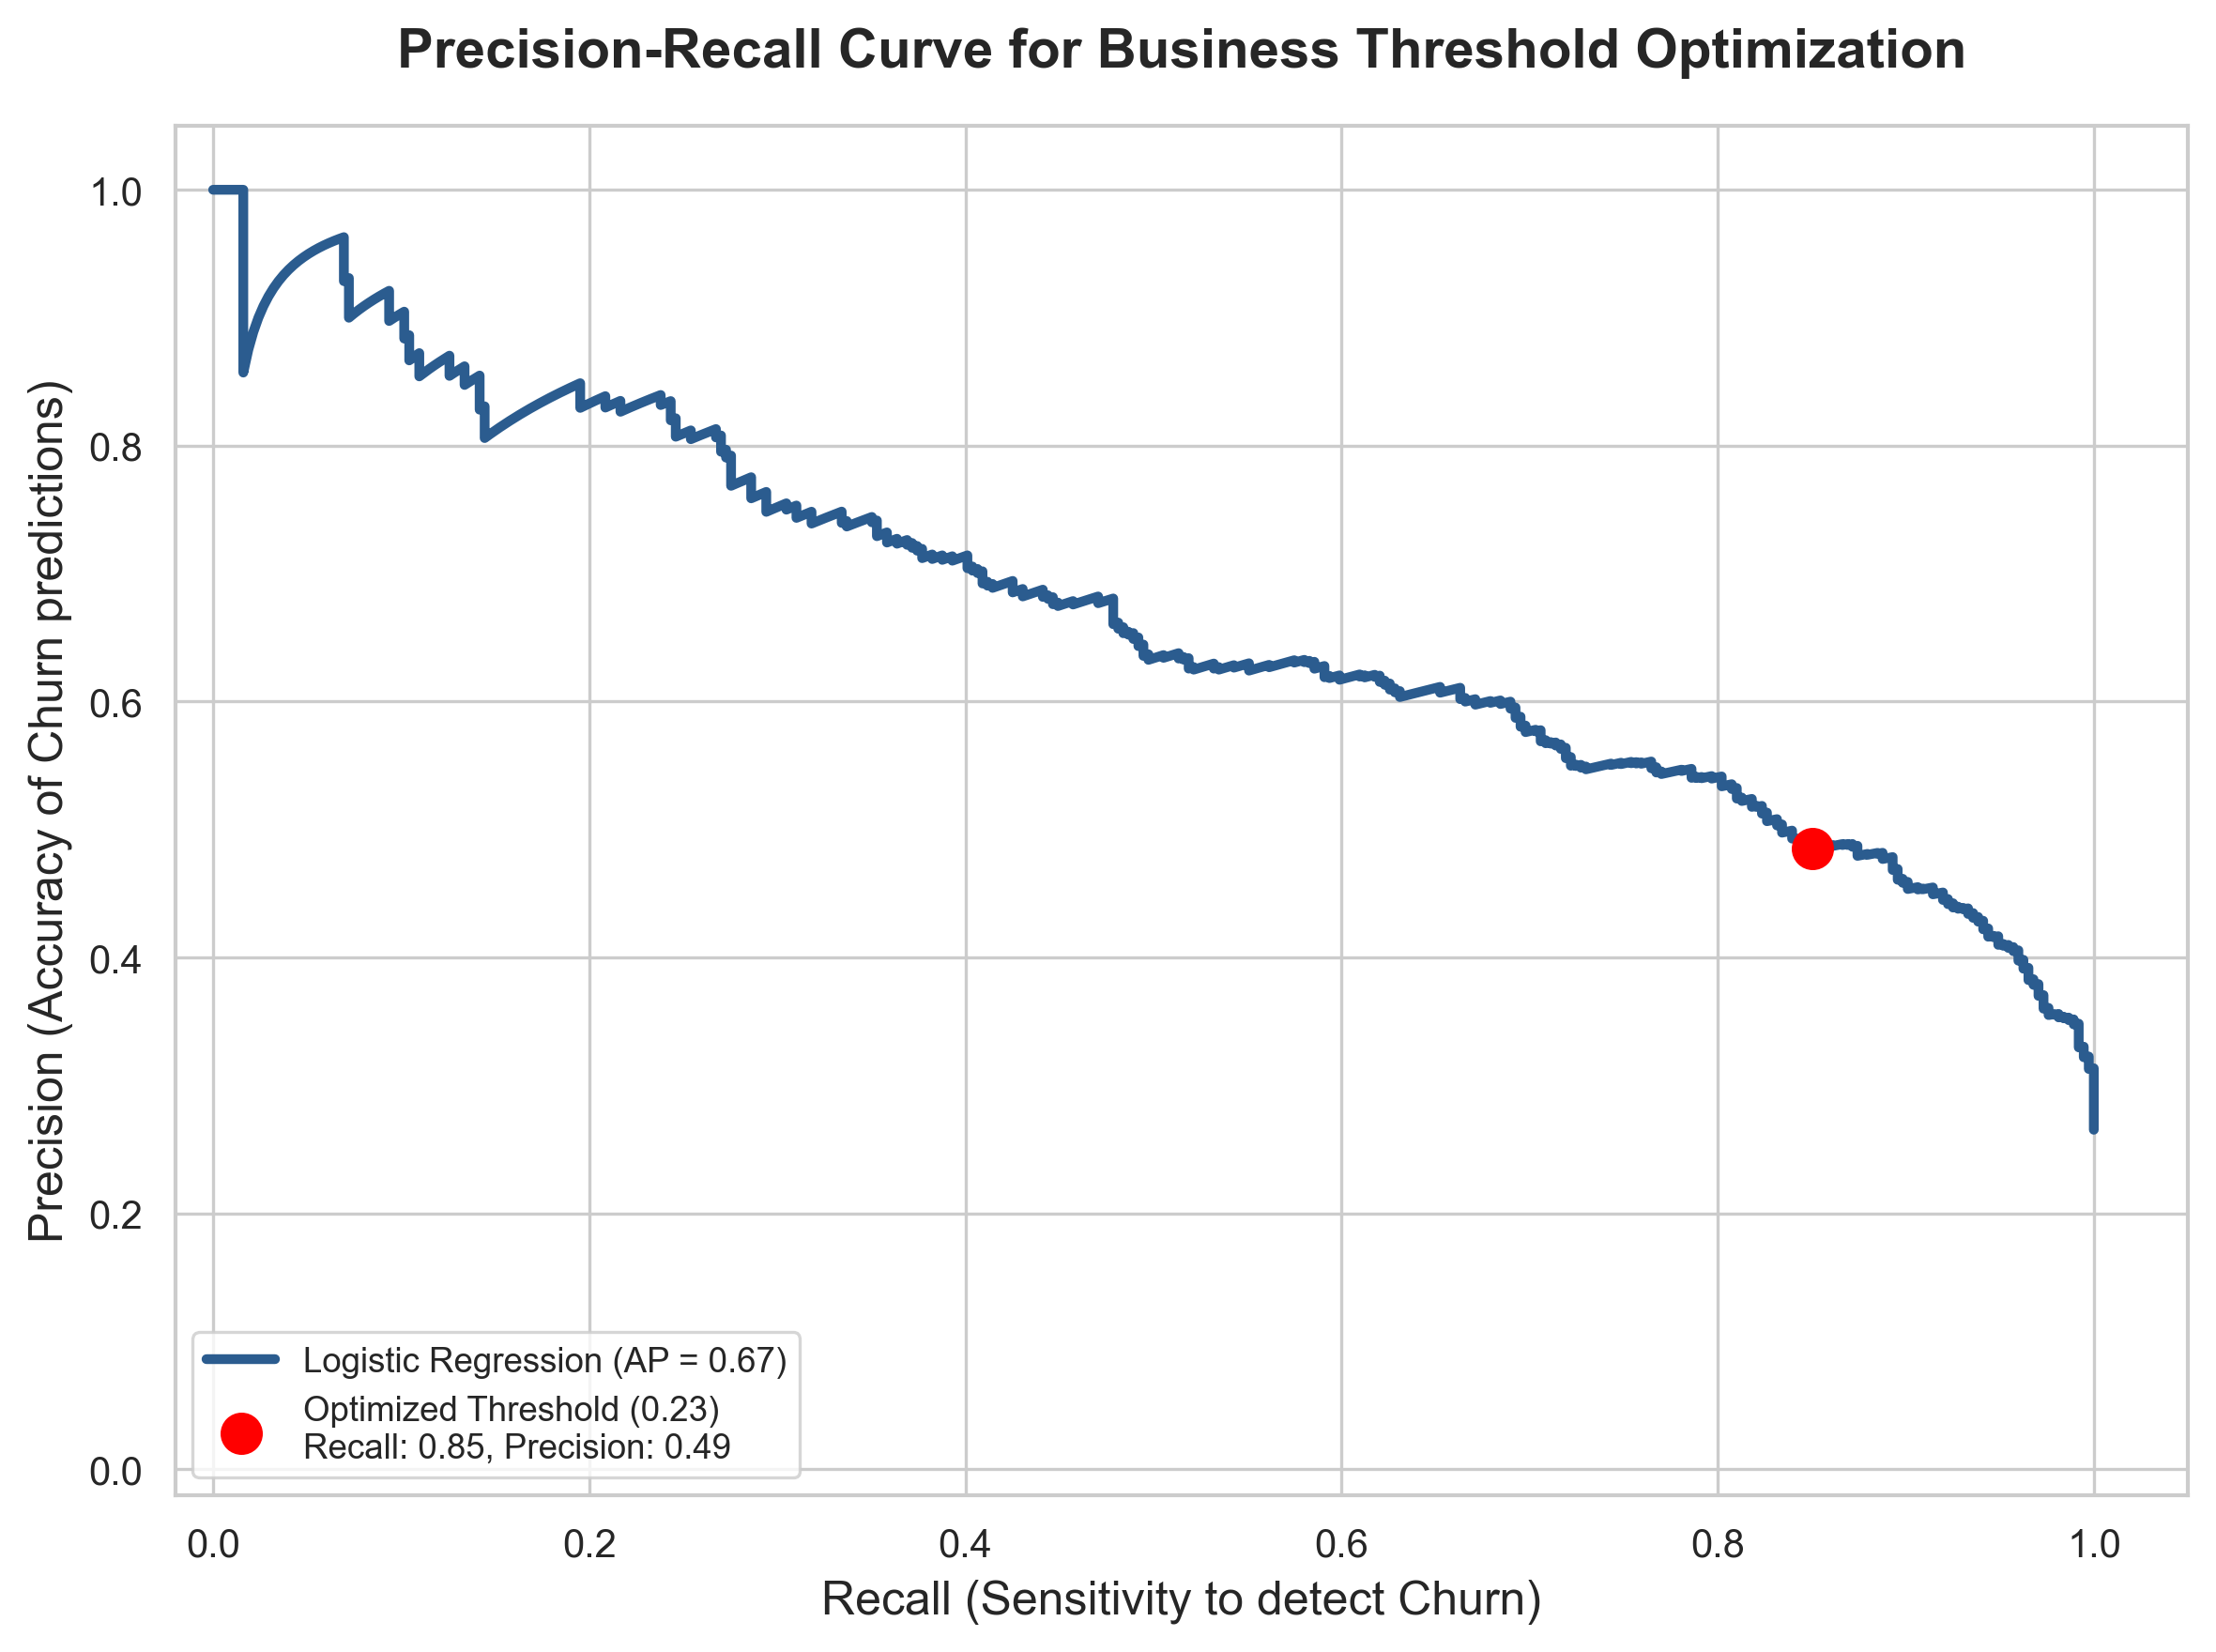

c:\Users\Muich\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Muich\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

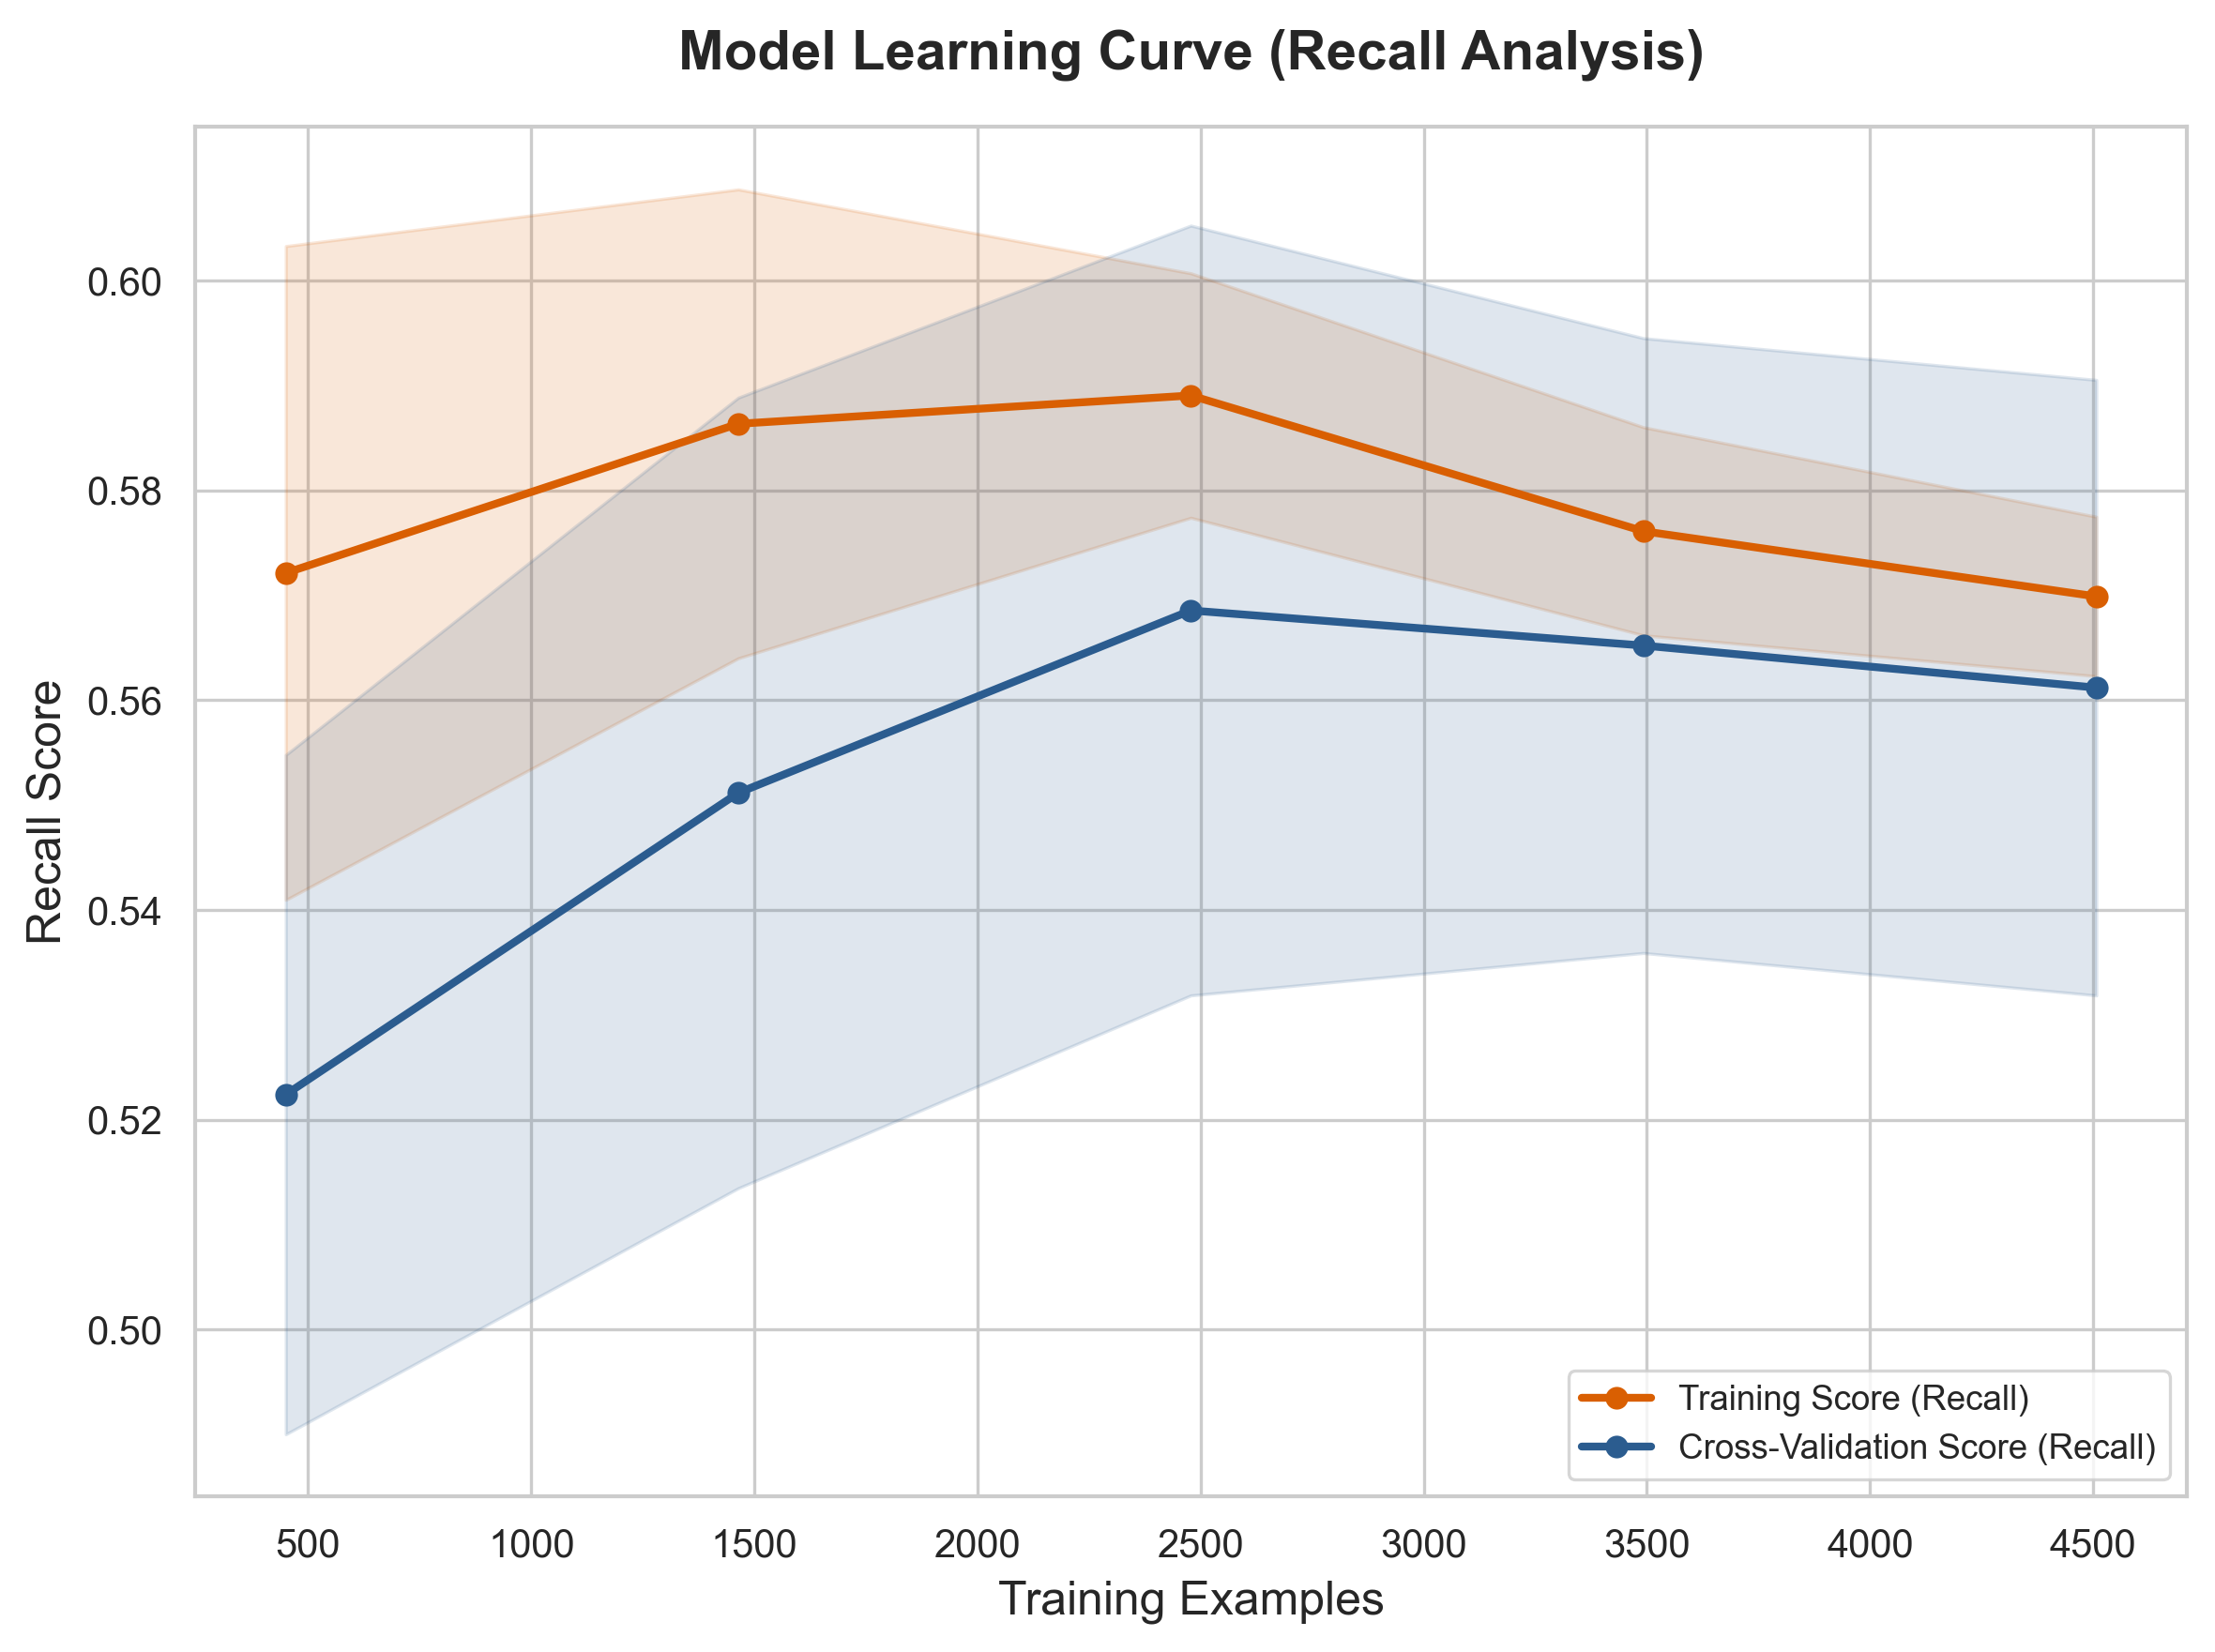

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.
C:\Users\Muich\AppData\Local\Temp\ipykernel_19372\1741842064.py:217: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_clean, show=False)


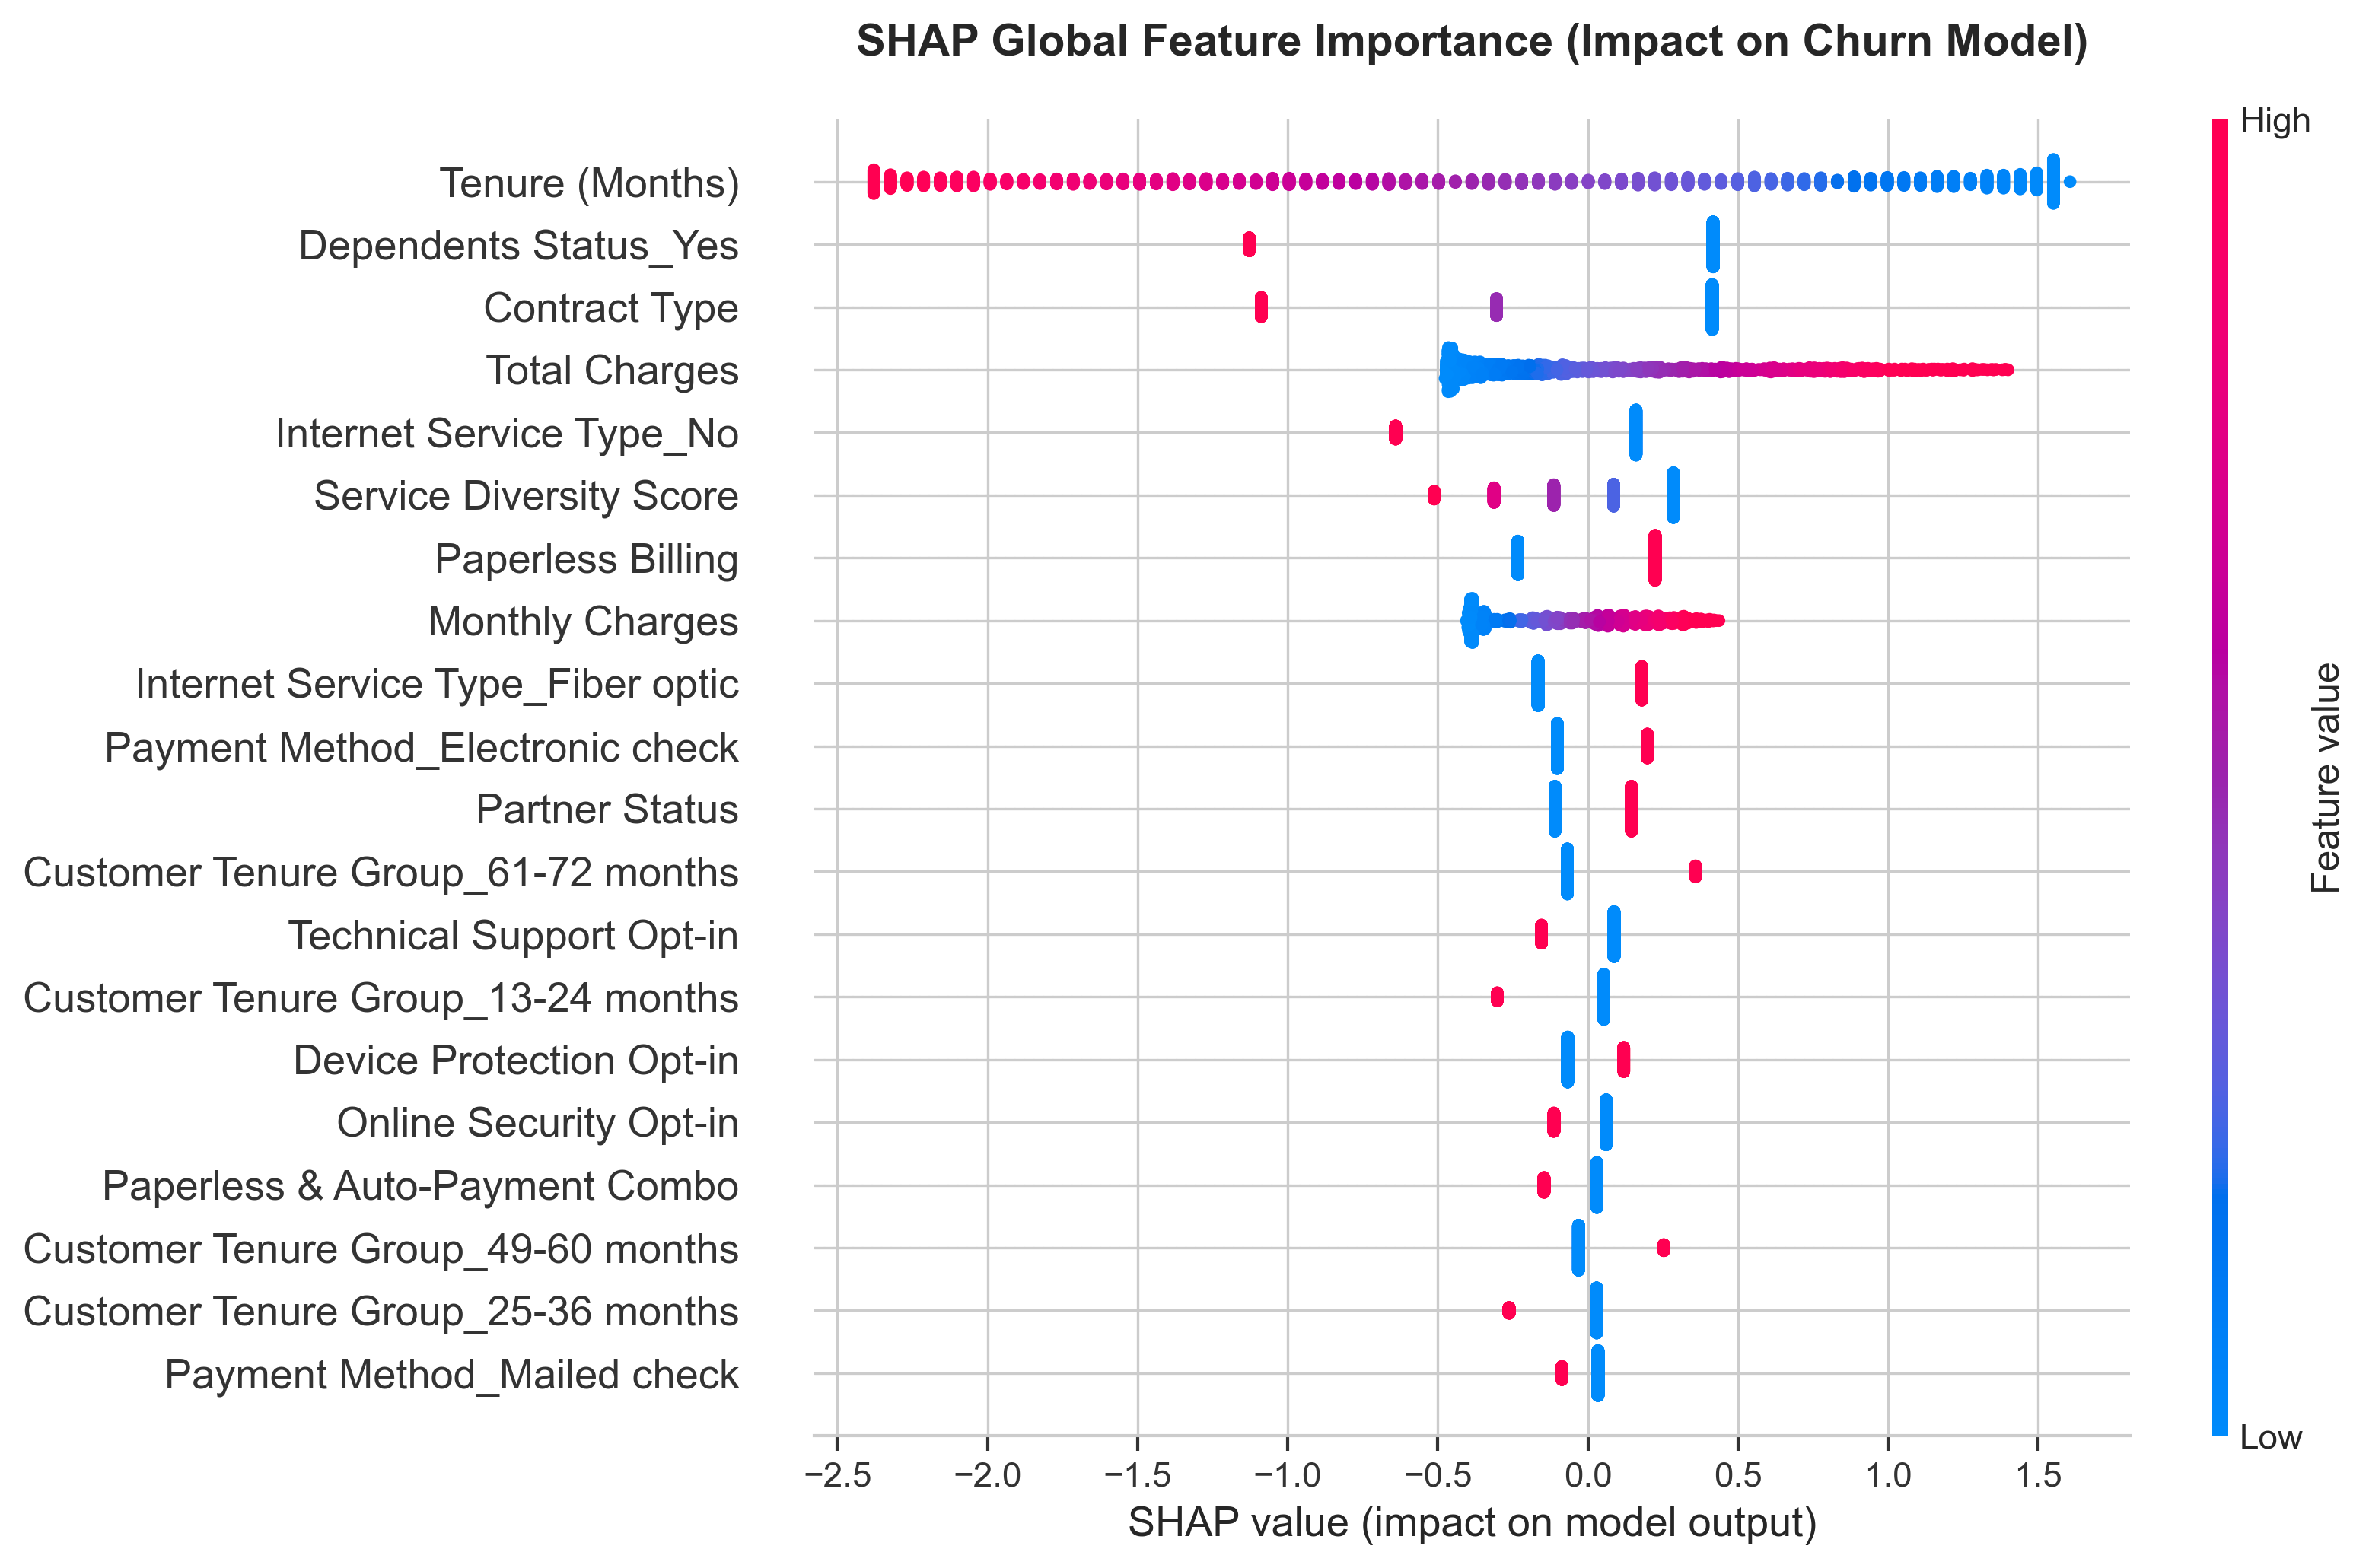

In [20]:
import os
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve
from sklearn.model_selection import GridSearchCV
# --- CẤU HÌNH HIỂN THỊ HỌC THUẬT (ĐẠT CHUẨN IN ẤN LATEX) ---
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# ==========================================
# AUTOMATED FEATURE CLEANING & MAPPING DICTIONARY
# ==========================================
# Danh sách tên cột thô lấy trực tiếp từ dữ liệu đầu vào
feature_names_raw = X_train.columns.tolist()

# Bảng từ điển ánh xạ chuẩn mực học thuật cho 18 đặc trưng cốt lõi của dự án
custom_names = {
    'Dependents': 'Dependents Status',
    'PaymentMethod': 'Payment Method',
    'InternetService': 'Internet Service Type',
    'tenure_group': 'Customer Tenure Group',
    'SeniorCitizen': 'Senior Citizen Status',
    'Partner': 'Partner Status',
    'Tenure': 'Tenure (Months)',
    'Contract': 'Contract Type',
    'PaperlessBilling': 'Paperless Billing',
    'MonthlyCharges': 'Monthly Charges',
    'TotalCharges': 'Total Charges',
    'OnlineSecurity': 'Online Security Opt-in',
    'OnlineBackup': 'Online Backup Opt-in',
    'DeviceProtection': 'Device Protection Opt-in',
    'TechSupport': 'Technical Support Opt-in',
    'service_diversity': 'Service Diversity Score',
    'monthly_charges_ratio': 'Monthly Charges Ratio',
    'is_paperless_electronic': 'Paperless & Auto-Payment Combo'
}

# Hàm dọn dẹp tự động: Xóa tiền tố rác hệ thống + Ánh xạ sang tên học thuật tiếng Anh 100%
def clean_and_map_features(raw_list, mapping_dict):
    cleaned_list = []
    for feat in raw_list:
        # 1. Loại bỏ triệt để tiền tố sinh ra từ Sklearn Pipeline
        clean_name = feat.replace('encoder__', '').replace('remainder__', '').replace('__', '_').strip()
        # 2. Tìm kiếm phần gốc trong bảng từ điển custom_names (Hỗ trợ tìm kiếm chuỗi con nếu có hậu tố One-Hot)
        mapped_name = clean_name
        for raw_key, academic_name in mapping_dict.items():
            if raw_key in clean_name:
                mapped_name = clean_name.replace(raw_key, academic_name)
                break
        cleaned_list.append(mapped_name)
    return cleaned_list

# Tạo danh sách tên biến đã được chuẩn hóa hoàn toàn
feature_names_clean = clean_and_map_features(feature_names_raw, custom_names)

# Tạo một dictionary hoàn chỉnh ánh xạ từ Tên thô -> Tên sạch phục vụ hàm .rename() của Pandas/SHAP
feature_mapping_final = dict(zip(feature_names_raw, feature_names_clean))


# ==========================================
# 0. ĐỊNH NGHĨA MODEL (Đảm bảo model đã được train)
# ==========================================
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train.values.ravel()) 

# ==========================================
# 1. ĐÁNH GIÁ MÔ HÌNH VỚI 5 CHỈ SỐ CỐT LÕI (METRICS EVALUATION)
# ==========================================
# SỬA LỖI: Chuyển Y_train -> y_train, Y_test -> y_test để khớp với Cell 2
# Dùng .values.ravel() để tránh warning dạng Column-Vector của Sklearn
y_train_true = y_train.values.ravel()
y_test_true = y_test.values.ravel()

y_train_pred = model.predict(X_train)
y_train_proba = model.predict_proba(X_train)[:, 1]

y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)[:, 1]

metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'Train Set': [
        accuracy_score(y_train_true, y_train_pred),
        precision_score(y_train_true, y_train_pred),
        recall_score(y_train_true, y_train_pred),
        f1_score(y_train_true, y_train_pred),
        roc_auc_score(y_train_true, y_train_proba)
    ],
    'Test Set': [
        accuracy_score(y_test_true, y_test_pred),
        precision_score(y_test_true, y_test_pred),
        recall_score(y_test_true, y_test_pred),
        f1_score(y_test_true, y_test_pred),
        roc_auc_score(y_test_true, y_test_proba)
    ]
})

print("="*60)
print("         MODEL PERFORMANCE METRICS SUMMARY REPORT")
print("="*60)
print(metrics_summary.to_string(index=False, formatters={'Train Set': '{:,.4f}'.format, 'Test Set': '{:,.4f}'.format}))
print("="*60)


# ==========================================
# 2. LOGISTIC REGRESSION: COEFFICIENTS BAR CHART
# ==========================================
coef_df = pd.DataFrame({
    'Raw_Feature': feature_names_raw,
    'Clean_Feature': feature_names_clean,
    'Coefficient': model.coef_[0]
})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#2b5c8f' if x >= 0 else '#d95f02' for x in coef_df['Coefficient']]

sns.barplot(
    x='Coefficient', 
    y='Clean_Feature', 
    data=coef_df, 
    hue='Clean_Feature', 
    palette=colors if sns.__version__ < '0.12.0' else None,
    legend=False
)

if sns.__version__ >= '0.12.0':
    ax = plt.gca()
    for bar, color in zip(ax.patches, colors):
        bar.set_facecolor(color)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1.2)
plt.title('Logistic Regression Coefficients (Direction & Impact)', fontweight='bold', pad=15)
plt.xlabel('Coefficient Value (Log-Odds Impact)')
plt.ylabel('Standardized Academic Features')
plt.tight_layout()
plt.show()


# ==========================================
# 3. ĐỒ THỊ PHÂN TÍCH NÂNG CAO (AI AUDIT LOG)
# ==========================================

# --- BIỂU ĐỒ 1: PRECISION-RECALL CURVE ---
# SỬA LỖI: Y_test -> y_test_true
precision, recall, thresholds = precision_recall_curve(y_test_true, y_test_proba)
avg_precision = average_precision_score(y_test_true, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='#2b5c8f', label=f'Logistic Regression (AP = {avg_precision:.2f})', linewidth=2.5)

idx_target_recall = (np.abs(recall - 0.85)).argmin()
target_threshold = thresholds[min(idx_target_recall, len(thresholds)-1)]

plt.scatter(
    recall[idx_target_recall], precision[idx_target_recall], 
    color='red', marker='o', s=100, zorder=5,
    label=f'Optimized Threshold ({target_threshold:.2f})\nRecall: {recall[idx_target_recall]:.2f}, Precision: {precision[idx_target_recall]:.2f}'
)

plt.title('Precision-Recall Curve for Business Threshold Optimization', fontweight='bold', pad=15)
plt.xlabel('Recall (Sensitivity to detect Churn)')
plt.ylabel('Precision (Accuracy of Churn predictions)')
plt.xlim([-0.02, 1.05])
plt.ylim([-0.02, 1.05])
plt.legend(loc="lower left", frameon=True)
plt.tight_layout()
plt.show()


# --- BIỂU ĐỒ 2: LEARNING CURVE ---
# SỬA LỖI: Y_train -> y_train_true
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train, y_train_true, cv=5, scoring='recall', 
    train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#d95f02', label='Training Score (Recall)', linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#d95f02')
plt.plot(train_sizes, test_mean, 'o-', color='#2b5c8f', label='Cross-Validation Score (Recall)', linewidth=2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='#2b5c8f')

plt.title('Model Learning Curve (Recall Analysis)', fontweight='bold', pad=15)
plt.xlabel('Training Examples')
plt.ylabel('Recall Score')
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()


# --- BIỂU ĐỒ 3: SHAP SUMMARY PLOT ---
X_train_clean = X_train.rename(columns=feature_mapping_final)
X_test_clean = X_test.rename(columns=feature_mapping_final)

explainer = shap.LinearExplainer(model, X_train_clean)
shap_values = explainer(X_test_clean)

shap.summary_plot(shap_values, X_test_clean, show=False)
fig = plt.gcf()
fig.set_size_inches(11, 7)

plt.title('SHAP Global Feature Importance (Impact on Churn Model)', fontweight='bold', pad=20, fontsize=14)
plt.tight_layout()
plt.show()